In [ ]:
# Instalando spectral
!pip install -q spectral rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 51.2 MB/s eta 0:00:00


In [ ]:
# Bibliotecas
from spectral import imshow
import numpy as np
import rasterio as rio
from rasterio.plot import reshape_as_image, reshape_as_raster
import matplotlib.pyplot as plt

In [ ]:
# Lendo imagem empilhada
with rio.open('/content/drive/MyDrive/Pós AmbGEO/CBERS_4A.tif') as src:
  cbers = src.read()
  meta = src.profile

In [ ]:
# Redimensionando
cbers_reshape = reshape_as_image(cbers)
cbers_reshape.shape

(4753, 5428, 4)

In [ ]:
# Função para a correção atmosférica
def DOS(img, perc=1):
  l_per = []
  img_corr = np.zeros_like(img)
  for i in range(img.shape[2]):
    per = (np.percentile(img[:,:,i][img[:,:,i]!=0], perc))
    l_per.append(per)
    img_corr[:,:,i] = img[:,:,i] - l_per[i]
    img_corr[:,:,i] = np.where(img_corr[:,:,i] > 0, img_corr[:,:,i] , 0)
  print(l_per)
  return img_corr

In [ ]:
# Aplicando função
dos = DOS(cbers_reshape)

[np.float64(147.0), np.float64(106.0), np.float64(78.0), np.float64(255.0)]


ImageView object:
  Display bands       :  (2, 1, 0)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(0.0), np.float64(275.0)]
    G: [np.float64(0.0), np.float64(213.0)]
    B: [np.float64(0.0), np.float64(228.0)]

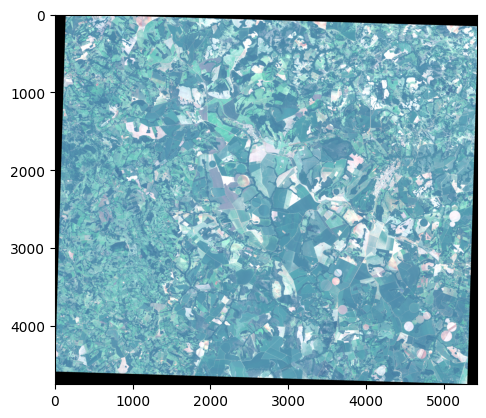

In [ ]:
# Visualização de uma composição colorida da imagem não corrigida
imshow(cbers_reshape, (2,1,0), stretch = (0.02, 0.98))

ImageView object:
  Display bands       :  (2, 1, 0)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(0.0), np.float64(197.0)]
    G: [np.float64(0.0), np.float64(107.0)]
    B: [np.float64(0.0), np.float64(81.0)]

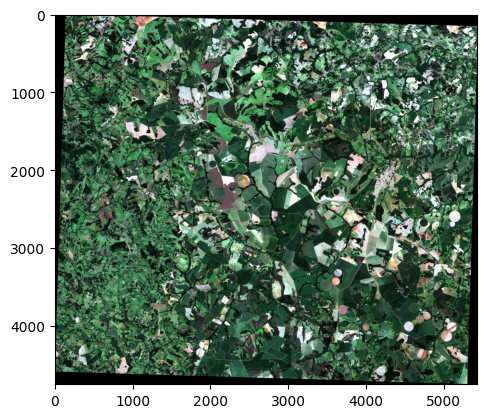

In [ ]:
# Visualização de uma composição colorida da imagem corrigida
imshow(dos, (2,1,0), stretch = (0.02, 0.98))